# Synthetic Valley Glacier
### Initalization to steady state for SIA/SSA Hybrid paper
01/2025

Eventually will add in lake calving front

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import geojson
import xarray
import rasterio
import firedrake
from firedrake import inner, grad, dx, ds, dS, exp, min_value, max_value, Constant, derivative, sqrt, ln, avg, jump, conditional
import icepack
from icepack2 import model
import irksome
import tqdm

## Domain Set Up

In [2]:
Lx, Ly = 40e3, 4e3 # Len/width ~ Tasman Glacier
#nx, ny = 160, 16 # Change these to change spatial res.
nx, ny = 80, 8 # Change these to change spatial res.

mesh = firedrake.RectangleMesh(nx, ny, Lx, Ly, diagonal='crossed')

cg1 = firedrake.FiniteElement("CG", "triangle", 1)
dg0 = firedrake.FiniteElement("DG", "triangle", 0)

Q = firedrake.FunctionSpace(mesh, dg0) # changed from cg1
V = firedrake.VectorFunctionSpace(mesh, cg1)

In [3]:
cell_sizes = mesh.cell_sizes.dat.data_ro

print(f'Cells: {mesh.num_cells()}')
print(f'Min: {cell_sizes.min():.3f} m')
print(f'Max: {cell_sizes.max():.3f} m')
print(f'Avg: {cell_sizes.mean():.3f} m')

Cells: 2560
Min: 500.000 m
Max: 500.000 m
Avg: 500.000 m


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


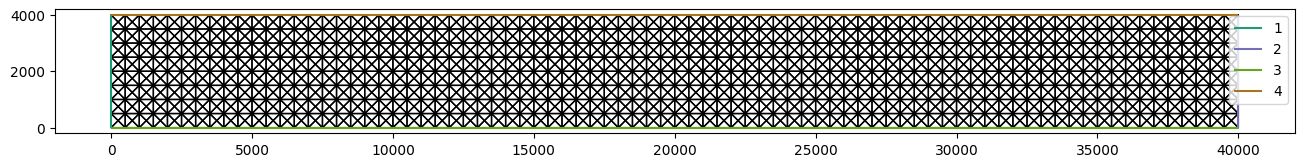

In [4]:
fig, ax = plt.subplots(figsize = (16, 8))
ax.set_aspect("equal")
firedrake.triplot(mesh, axes=ax)
ax.legend();

In [5]:
x, y = firedrake.SpatialCoordinate(mesh)

b_in, b_out = 2900, 0
δb1, δb2 = 0.145, -0.000002
δby = 250

b_expr = b_in - (δb1*x) - (δb2*x**2) - 4 * δby * (y/Ly)*(1 - y/Ly)
b = firedrake.project(b_expr, Q)

h_in, h_max = 0, 500

lx = 3 * Lx / 5

x0 = Constant(1e3)
y0 = Constant(500)

h_expr = 16 * h_max * ((x - x0) / lx) * (1 - (x- x0) / lx) * ((y) / Ly) * (1 - (y) / Ly)
h0 = firedrake.project(firedrake.max_value(0.01, h_expr), Q)

s0 = firedrake.project(h0 + b, Q)

/opt/firedrake/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/opt/firedrake/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


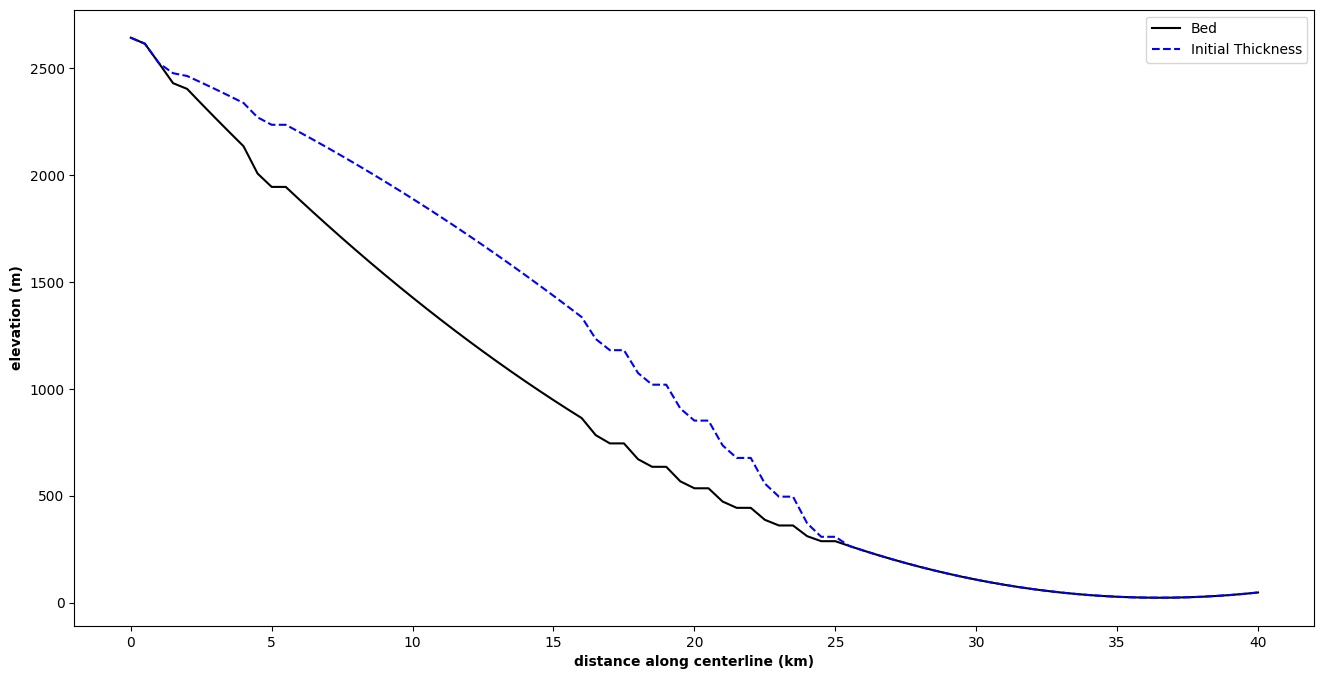

In [6]:
xs = np.array([(Lx * k / nx, Ly / 2) for k in range(nx + 1)])

s0s = np.array(s0.at(xs, tolerance=1e-10))
bs  = np.array(b.at(xs, tolerance=1e-10))

fig, axes = plt.subplots(figsize = (16, 8))
axes.plot(xs[:, 0] / 1e3, bs, color="black", label = "Bed")
axes.plot(xs[:, 0] / 1e3, s0s, linestyle = 'dashed', color="blue", label = "Initial Thickness")
axes.set_xlabel("distance along centerline (km)", fontweight = 'bold')
axes.set_ylabel("elevation (m)", fontweight = 'bold')
axes.legend()

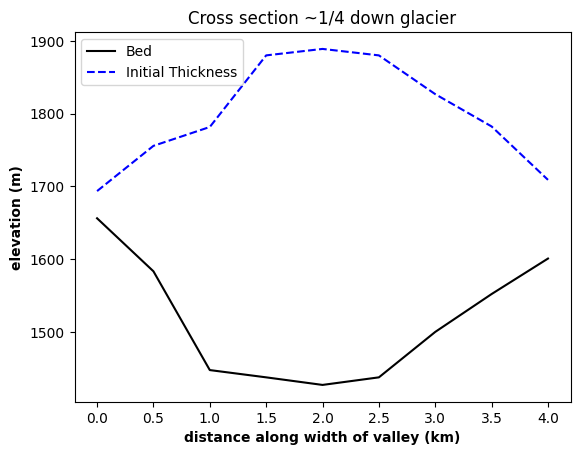

In [7]:
ys = np.array([(Lx/4, Ly * k / ny) for k in range(ny + 1)])

by = np.array(b.at(ys, tolerance=1e-10))
s0y = np.array(s0.at(ys, tolerance=1e-10))

fig, axes = plt.subplots()
axes.plot(ys[:,1] / 1e3, by, color="black", label = "Bed")
axes.plot(ys[:,1] / 1e3, s0y,  linestyle = 'dashed', color="blue", label = "Initial Thickness")
axes.set_xlabel("distance along width of valley (km)", fontweight = 'bold')
axes.set_ylabel("elevation (m)", fontweight = 'bold')
axes.set_title("Cross section ~1/4 down glacier")
axes.legend()

fig = plt.figure(figsize = (10, 16))
axes = fig.add_subplot(projection="3d")
#axes.set_box_aspect((17.5, 2.0, 0.6))
axes.set_axis_off()
#firedrake.trisurf(b, axes=axes);
firedrake.trisurf(s0, axes=axes);

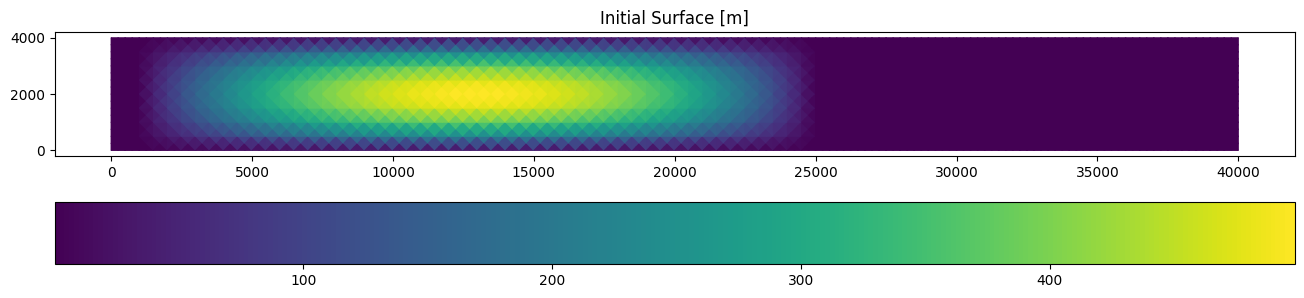

In [8]:
fig, ax = plt.subplots(figsize = (16, 12))
ax.set_aspect("equal")
colors = firedrake.tripcolor(h0, axes=ax)
fig.colorbar(colors, orientation = 'horizontal', pad = 0.05)
ax.set_title('Initial Surface [m]');

## Initial Calculations
Some notes:
- Organizing as a friction based model to examine how this will effect hybrid set up
- DG0 elements require conjugate gradient method due to discontinous surface elements
- SIA velocity using driving stress rather than surface to get around DG elements

### Initial Driving Stress

In [9]:
from icepack2.constants import gravity as g, ice_density as ρ_I, glen_flow_law as n

# Method for DG0 surface
ρ = Constant(ρ_I)
g = Constant(g)

τ_d = firedrake.Function(V)
σ = firedrake.TestFunction(V)
ν = firedrake.FacetNormal(mesh)

F_cells = (inner(τ_d, σ) + ρ*g*h0 * inner(grad(s0), σ)) * dx
F_facets = -inner(avg(ρ*g*h0) * jump(s0, ν), avg(σ)) * dS
F = F_cells + F_facets

firedrake.solve(F == 0, τ_d)

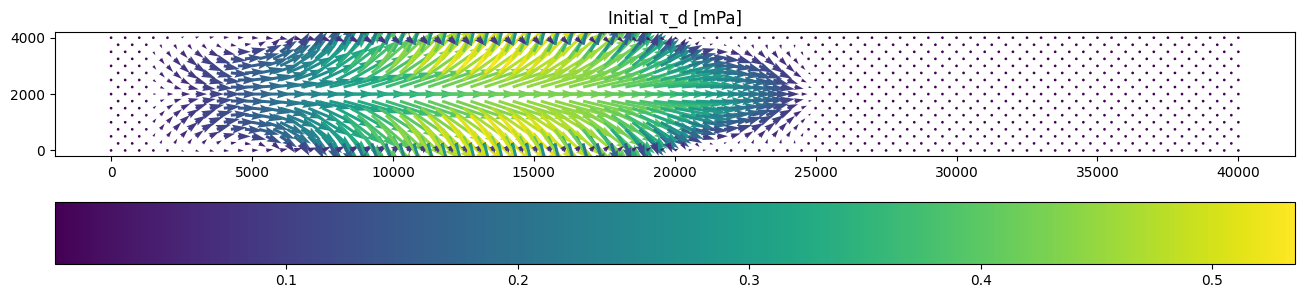

In [10]:
fig, ax = plt.subplots(figsize = (16, 12))
ax.set_aspect("equal")
colors = firedrake.quiver(τ_d, axes=ax)
fig.colorbar(colors, orientation = 'horizontal', pad = 0.05)
ax.set_title('Initial τ_d [mPa]');

### Initial SIA Velocity

In [11]:
T = Constant(273.15) #268
CS = firedrake.FunctionSpace(mesh, "R", 0)

A = firedrake.Function(CS)
A.assign(icepack.rate_factor(T))

Coefficient(WithGeometry(FunctionSpace(<firedrake.mesh.MeshTopology object at 0x7c8115626660>, FiniteElement('Real', triangle, 0), name=None), Mesh(VectorElement(FiniteElement('Lagrange', triangle, 1), dim=2), 0)), 79)

In [12]:
from icepack import rate_factor
from icepack2.constants import gravity as g, ice_density as ρ, glen_flow_law as n

u = firedrake.Function(V)
v = firedrake.TestFunction(V)

#P = ρ * g * h0
u_shear = (-2/(n+2)) * h0 * A * (inner(τ_d, τ_d) ** 0.5) ** (n-1) * τ_d

F = inner(u - u_shear, v) * dx

solver_params = {"snes_type": "ksponly", "ksp_type": "gmres"}
fc_params = {"quadrature_degree": 6}
params = {"solver_parameters": solver_params, "form_compiler_parameters": fc_params}
firedrake.solve(F == 0, u, **params)

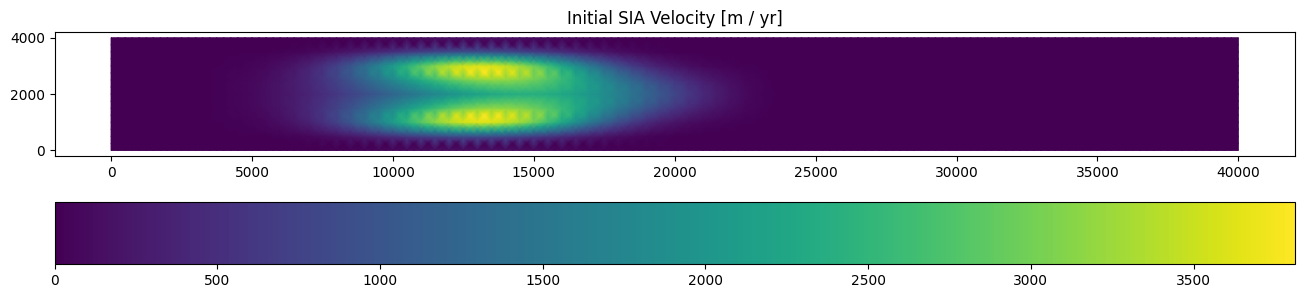

In [13]:
fig, ax = plt.subplots(figsize = (16, 12))
ax.set_aspect("equal")
colors = firedrake.tripcolor(u, axes=ax)
fig.colorbar(colors, orientation = 'horizontal', pad = 0.05)
ax.set_title('Initial SIA Velocity [m / yr]');

### Basal Friction From SIA Velocity

How can we tie this in to the overall sliding at the bed? The fraction of resisting stress that is related to driving stress in the weertman law determines the amount of sliding. This should inform where we sit on the spectrum between SIA and SSA.

In [14]:
from icepack.constants import weertman_sliding_law
m = Constant(weertman_sliding_law)
frac = Constant(0.8) #0.8 -- fraction of driving stress related to resisting stress
C_obs = frac * sqrt(inner(τ_d, τ_d)) / sqrt(inner(u, u)) ** (1 / m)
C = firedrake.Function(Q)
α = Constant(0.0)
J = 0.5 * ((C - C_obs)**2 + α**2 * inner(grad(C), grad(C))) * dx
F = firedrake.derivative(J, C)

firedrake.solve(F == 0, C)

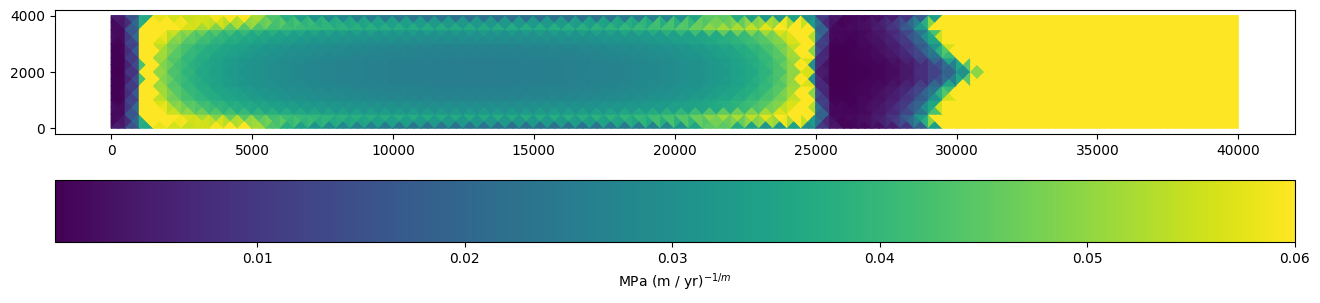

In [15]:
fig, ax = plt.subplots(figsize = (16, 12))
ax.set_aspect("equal")
colors = firedrake.tripcolor(C, axes=ax, vmax = 0.06)
fig.colorbar(colors, orientation = 'horizontal', pad = 0.05, label="MPa (m / yr)${}^{-1/m}$");

In [16]:
area = firedrake.assemble(Constant(1) * dx(mesh))
C_avg = firedrake.assemble(C * dx) / area

print(f"Average friction coefficient: {1e3 * C_avg:.3f} kPa / (meters / year)^(1 / m)")

Average friction coefficient: 211.529 kPa / (meters / year)^(1 / m)


In [17]:
q = firedrake.Function(Q).interpolate(ln(C / C_avg))

In [18]:
h = h0.copy(deepcopy = True)
s = s0.copy(deepcopy = True)

In [19]:
expr = C_avg * exp(q) * sqrt(inner(u, u))**(1 / m)
τ_b = firedrake.Function(Q).interpolate(expr)

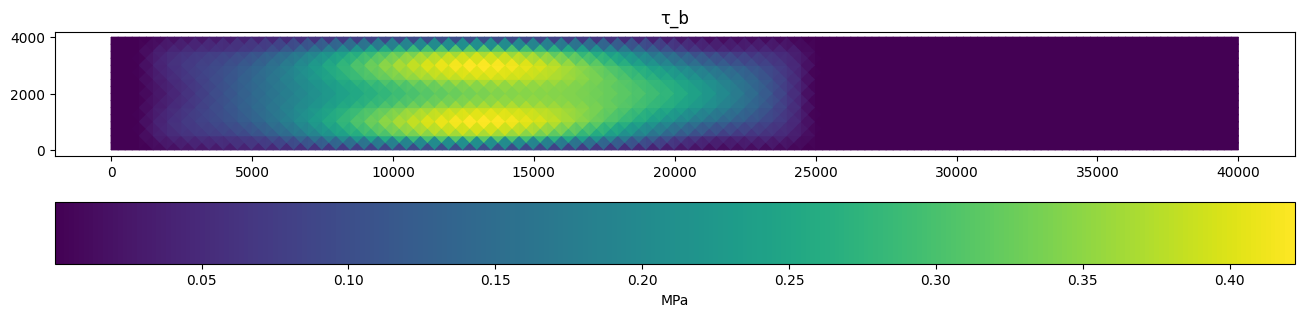

In [20]:
fig, ax = plt.subplots(figsize = (16, 12))
ax.set_aspect("equal")
colors = firedrake.tripcolor(τ_b, axes=ax)
fig.colorbar(colors, label="MPa", orientation = 'horizontal', pad = 0.05)
ax.set_title('τ_b');

In [21]:
expr = sqrt(inner(τ_d, τ_d)) / C_avg * exp(q) * sqrt(inner(u, u)) ** (1 / m) 
stress_ratio = firedrake.Function(Q).interpolate(expr)

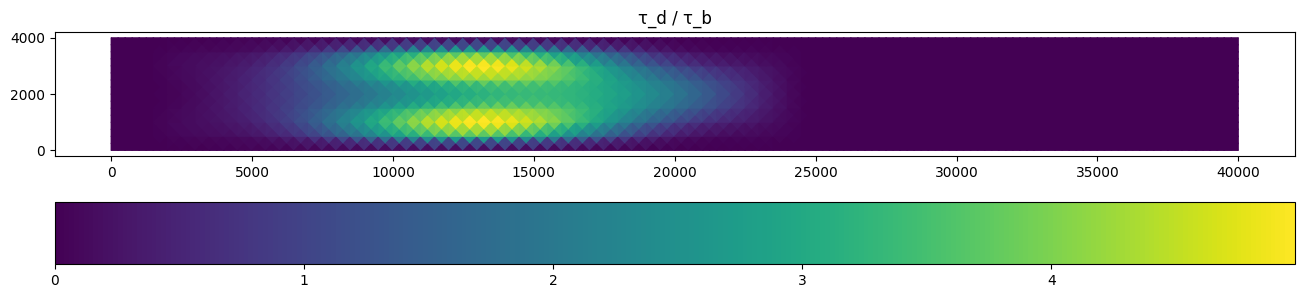

In [22]:
fig, ax = plt.subplots(figsize = (16, 12))
ax.set_aspect("equal")
colors = firedrake.tripcolor(stress_ratio, axes=ax)
fig.colorbar(colors, orientation = 'horizontal', pad = 0.05)
ax.set_title('τ_d / τ_b');

## Dual Form Fwd Model

### Initial dual solve

In [23]:
dg0 = firedrake.FiniteElement("DG", "triangle", 0)
Σ = firedrake.TensorFunctionSpace(mesh, dg0, symmetry=True)
T = firedrake.VectorFunctionSpace(mesh, cg1)
Z = V * Σ * T
z = firedrake.Function(Z)

z.sub(0).assign(u);

In [24]:
fns = [
    model.viscous_power,
    model.friction_power,
    model.momentum_balance,
    #model.calving_terminus,
]

AttributeError: module 'icepack2.model' has no attribute 'viscous_power'

In [ ]:
τ_c = Constant(0.1) # Critical Stress (set to 0.1 mPa)
ε_c = Constant(A * τ_c ** n) # multiply by very small Λ for SIA-like

K = h * A / (n + 2)
U_c = Constant(100.0) # Critical velocity -> 0 completely turns of long. stress (SIA-like)
u_c = K * τ_c ** n + U_c

In [25]:
print(τ_c)
print(ε_c)
print(U_c)

NameError: name 'τ_c' is not defined

In [27]:
rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c ** n,
    "sliding_exponent": n,
    "sliding_coefficient": u_c / τ_c ** n,
}

u, M, τ = firedrake.split(z)
fields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": h,
    "surface": s,
}

L = sum(fn(**fields, **rheology) for fn in fns)
F = derivative(L, z)

In [28]:
h_min = Constant(1e-5) #LHS modification

rfields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": firedrake.max_value(h_min, h),
    "surface": s,
}

L_r = sum(fn(**rfields, **rheology) for fn in fns)
F_r = firedrake.derivative(L_r, z)
J_r = firedrake.derivative(F_r, z)

In [29]:
v_c = firedrake.replace(u_c, {h: firedrake.max_value(h, h_min)})
linear_rheology = {
    "flow_law_exponent": 1,
    "flow_law_coefficient": ε_c / τ_c,
    "sliding_exponent": 1,
    "sliding_coefficient": v_c / τ_c,
}

L_1 = sum(fn(**rfields, **linear_rheology) for fn in fns)
F_1 = firedrake.derivative(L_1, z)
J_1 = firedrake.derivative(F_1, z)

In [30]:
λ = Constant(1e-5)
J = J_r + λ * J_1 # nudge near zero for the init. sliding law 

In [31]:
degree = 1
qdegree = max(8, degree ** n)
pparams = {"form_compiler_parameters": {"quadrature_degree": qdegree}}
momentum_problem = firedrake.NonlinearVariationalProblem(F, z, J=J, **pparams)

In [32]:
sparams = {
    #"snes_monitor": None,
    "snes_type": "newtonls", #tr
    "snes_max_it": 200,
    #"snes_converged_reason": None,
    "snes_linesearch_type": "nleqerr",
    "snes_rtol" : 1e-5,
    "ksp_type": "gmres",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "umfpack", #mumps
}
momentum_solver = firedrake.NonlinearVariationalSolver(momentum_problem, solver_parameters=sparams)

In [33]:
momentum_solver.solve()

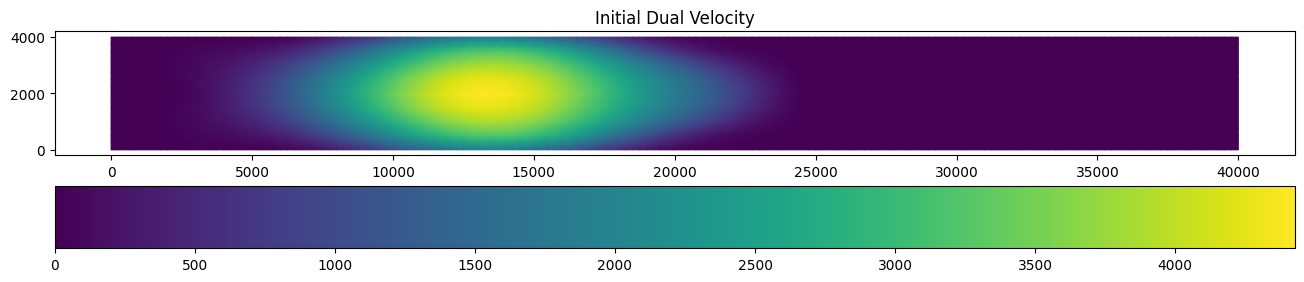

In [34]:
u, M, τ = z.subfunctions

fig, axes = plt.subplots(figsize = (16, 8))
axes.set_title('Initial Dual Velocity')
axes.set_aspect("equal")
colors = firedrake.tripcolor(u, axes=axes)
fig.colorbar(colors, orientation = 'horizontal', pad = 0.05)

### $\tau_b$ from Dual Form

In [35]:
expr = C_avg * exp(q) * sqrt(inner(u, u))**(1 / m)
τ_b = firedrake.Function(Q).interpolate(expr)

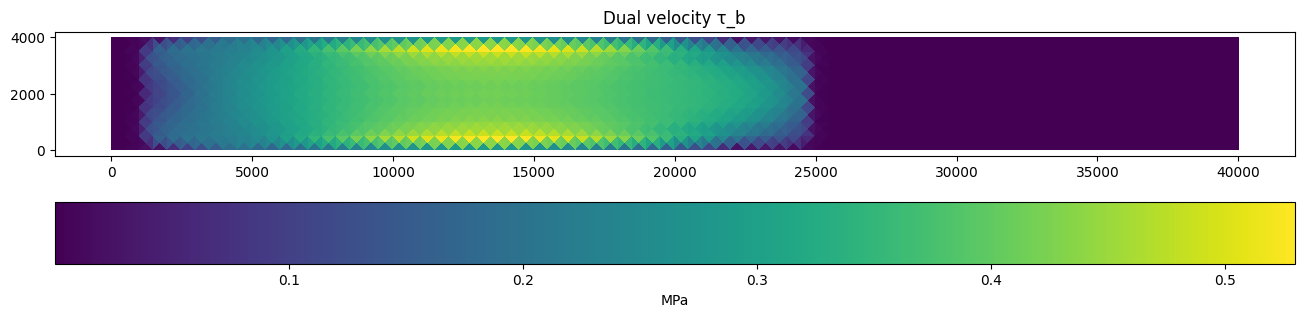

In [36]:
fig, ax = plt.subplots(figsize = (16, 12))
ax.set_aspect("equal")
colors = firedrake.tripcolor(τ_b, axes=ax)
fig.colorbar(colors, label="MPa", orientation = 'horizontal', pad = 0.05)
ax.set_title('Dual velocity τ_b');

## SMB model

In [37]:
print(f'S: {s0.dat.data_ro.min():.2f} - {s0.dat.data_ro.max():.2f} m \n ΔS: {s0.dat.data_ro.max() - s0.dat.data_ro.min():.2f} m')

S: 22.56 - 2843.72 m 
 ΔS: 2821.17 m


In [38]:
s_min = s.dat.data_ro.min()
s_max = s.dat.data_ro.max()
s_diff = int(np.round(s_max - s_min))
s_vals = np.linspace(s_min, s_max, s_diff)

a_vals = np.zeros(s_diff)

Text(0, 0.5, 'Elevation [m asl]')

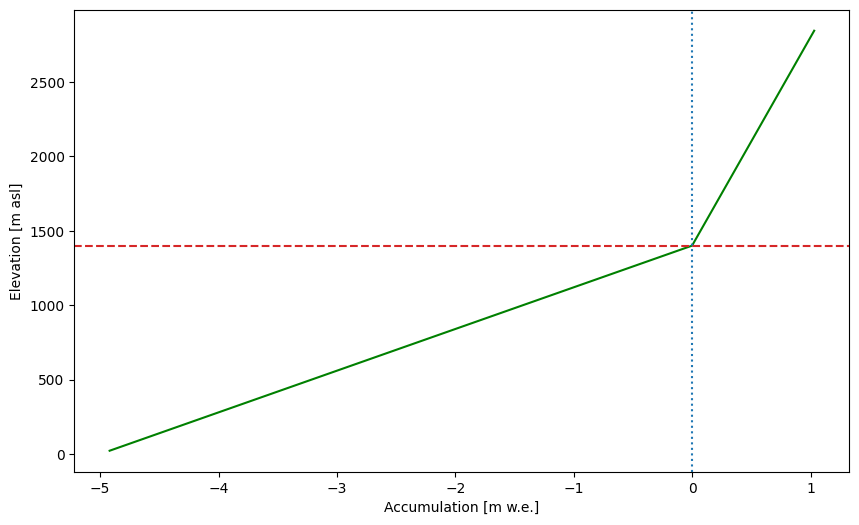

In [39]:
# Current obs vals:
# ela = 1650, abl_start and accu = -13, a_max = 5

ela = 1400
abl_start = -5                      # b_t
abl_m = (-1 * abl_start) / ela

acu_start = -1
accum_m = (-1 * acu_start) / ela

a_max = 100

for i in range(len(s_vals)):
    if s_vals[i] < ela:
        a_vals[i] = min_value(a_max, abl_start + abl_m * s_vals[i])
    elif s_vals[i] == ela:
        a_vals[i] = 0
    elif s_vals[i] > ela:
        a_vals[i] = min_value(a_max, acu_start + accum_m * s_vals[i-1])

plt.figure(figsize = (10,6))
plt.plot(a_vals, s_vals, color = 'green')
plt.axhline(y = ela, linestyle = '--', color = 'tab:red')
plt.axvline(x = 0, linestyle = 'dotted', color = 'tab:blue')
plt.xlabel('Accumulation [m w.e.]')
plt.ylabel('Elevation [m asl]')

In [40]:
# Changing a, don't fuck w timestep rn (we get to that later)
expr2 = conditional(
    ela >= s,
    abl_start + abl_m * s,
    0,
)

expr = conditional(
    ela < s,                                        #condition
    min_value(a_max, acu_start + accum_m * s),      # true val
    expr2,                                          # false val
)

def smb(s):
    return expr

In [41]:
a = firedrake.Function(Q).interpolate(smb(s))

print(f'Net Accumulation: {a.dat.data_ro.mean():.2f} m w.e.')
print(f'Sum Accumulation: {a.dat.data_ro.sum():.2f} m w.e.')

Net Accumulation: -1.97 m w.e.
Sum Accumulation: -5055.93 m w.e.


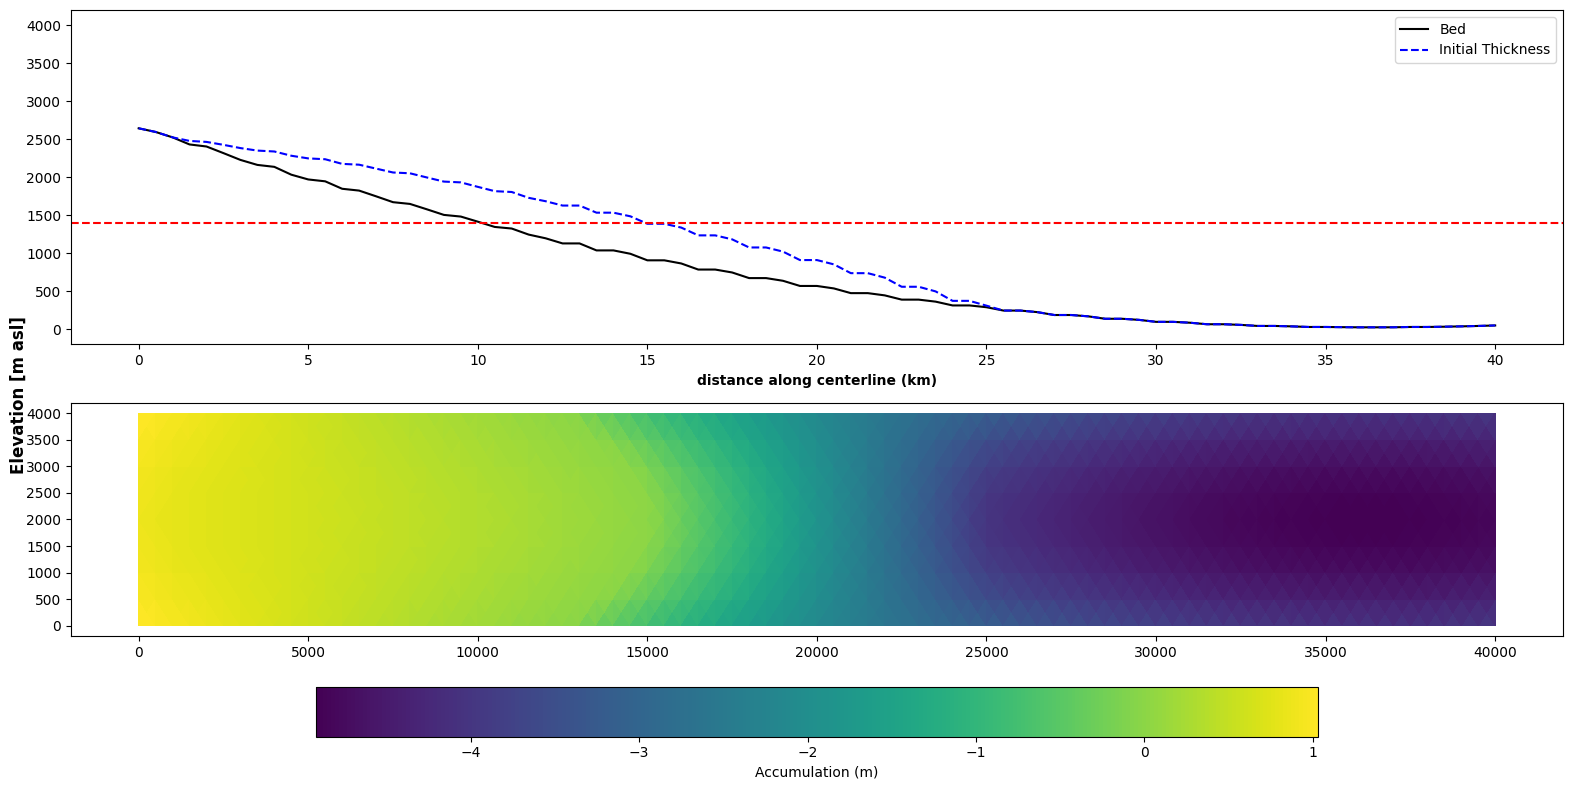

In [42]:
fig, axes = plt.subplots(2, 1, figsize = (16, 8), sharey=True)
axes[0].plot(xs[:, 0] / 1e3, bs, color="black", label = "Bed")
axes[0].plot(xs[:, 0] / 1e3, s0s, linestyle = 'dashed', color="blue", label = "Initial Thickness")
axes[0].set_xlabel("distance along centerline (km)", fontweight = 'bold')
axes[0].axhline(y = ela, linestyle = '--', color = 'red')
axes[0].legend()

colors = firedrake.tripcolor(a, axes=axes[1])
fig.colorbar(colors, label="Accumulation (m)", orientation = 'horizontal')

fig.supylabel('Elevation [m asl]', fontweight = 'bold')
fig.tight_layout()

In [43]:
ϕ = firedrake.TestFunction(Q)
G = model.mass_balance(thickness=h, velocity=u, accumulation=a, test_function=ϕ)
tableau = irksome.BackwardEuler()
t = Constant(0.0)
dt = Constant(1.0 / 6)

sparams = {
    "solver_parameters": {
        "ksp_type": "gmres",
        "pc_type": "ilu",
    },
}
mass_solver = irksome.TimeStepper(G, tableau, t, dt, h, **sparams)

/home/firedrake/firedrake/src/firedrake/firedrake/constant.py:73: FutureWarning: Giving Constants a domain is no longer supported. Instead please create a Function in the Real space.
  warnings.warn(


### Prognostic Solve (FWD Model) to Steady State

In [44]:
# Run Params

hs = [h.copy(deepcopy=True)]
us = [u.copy(deepcopy=True)]
a_s = [a.copy(deepcopy=True)]

start_time = 0.0 
final_time = 1500.0 # Want a 10k year run
num_steps = int(final_time / float(dt))
timesteps = np.linspace(start_time, final_time, num_steps + 1)

a_noiseSTD  = 0.5
a_noise = np.random.normal(0, a_noiseSTD, size=num_steps)

dh_max = np.zeros(num_steps) * np.nan

In [45]:
a_noise.shape

(9000,)

In [46]:
# THE L00000000000000000000000000000000000000000000000000P
with firedrake.CheckpointFile('valleyGlacier-Steady_sVar_hiRe.h5', "w") as chk:
    #u, M, τ = z.subfunctions
    chk.save_function(h, name="thickness", idx=0)
    chk.save_function(u, name="velocity", idx=0)
    chk.save_function(M, name="membrane_stress", idx=0)
    chk.save_function(τ, name="basal_stress", idx=0)

    for step in tqdm.trange(num_steps):
        u, M, τ = z.subfunctions
        
        mass_solver.advance()
        h.interpolate(max_value(0, h))
        s.interpolate(b + h)
        
        a.interpolate(smb(s))
        a_con = Constant(a_noise[step])
        a.interpolate(a + a_con) 
        
        momentum_solver.solve()
    
        hs.append(h.copy(deepcopy=True))
        a_s.append(a.copy(deepcopy=True))
        us.append(z.subfunctions[0].copy(deepcopy=True))
        dh_max[step] = h.dat.data_ro.max()
                
        chk.save_function(h, name="thickness", idx=step + 1)
        chk.save_function(u, name="velocity", idx=step + 1)
        chk.save_function(M, name="membrane_stress", idx=step + 1)
        chk.save_function(τ, name="basal_stress", idx=step + 1)
        chk.save_function(s, name="surface_height", idx=step + 1)

    chk.save_function(b, name = "bed", idx=step + 1)    
    chk.save_function(q, name = "log_friction")

    chk.h5pyfile.create_dataset("timesteps", data=timesteps) # change to array of timestep vals

100%|████████████████████████████████████████| 9000/9000 [25:30<00:00,  5.88it/s]


### Result Plots

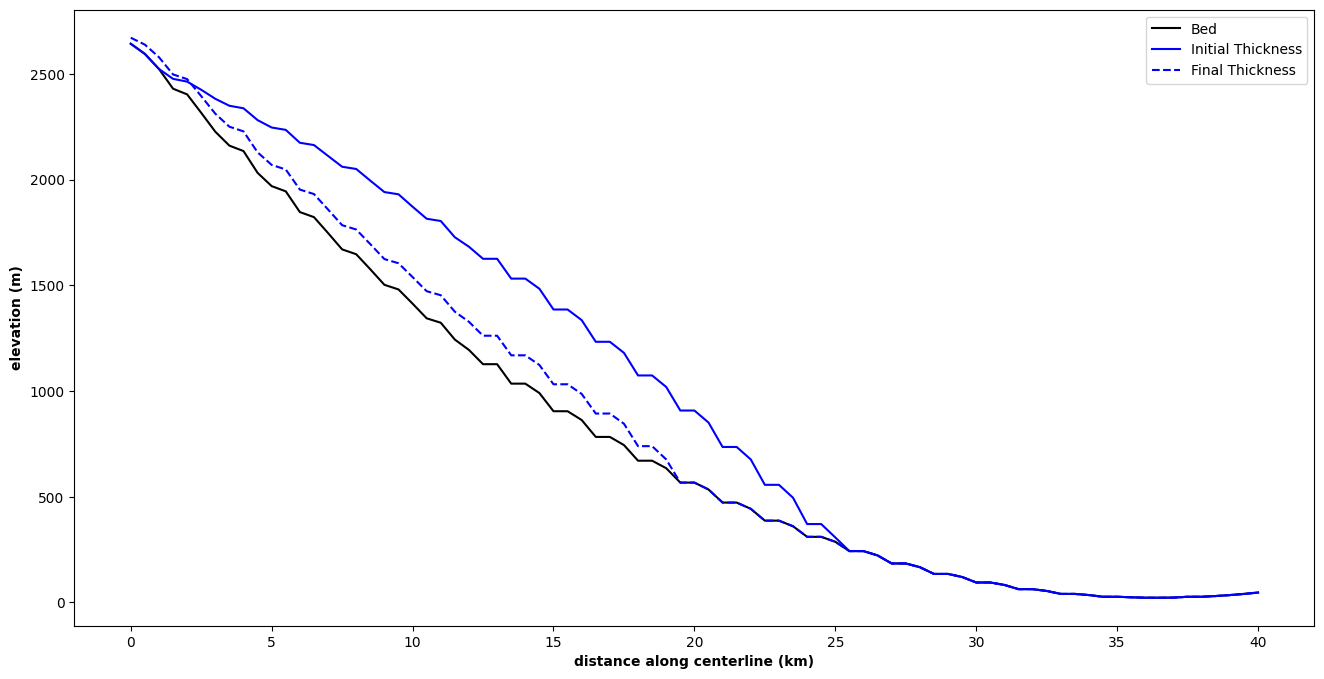

In [47]:
xs = np.array([(Lx * k / nx, Ly / 2) for k in range(nx + 1)])

s0s = np.array(s0.at(xs, tolerance=1e-10))
sns = np.array(s.at(xs, tolerance=1e-10))
bs  = np.array(b.at(xs, tolerance=1e-10))

fig, axes = plt.subplots(figsize = (16, 8))
axes.plot(xs[:, 0] / 1e3, bs, color="black", label = "Bed")
axes.plot(xs[:, 0] / 1e3, s0s, color="blue", label = "Initial Thickness")
axes.plot(xs[:, 0] / 1e3, sns, linestyle = 'dashed', color="blue", label = "Final Thickness")
axes.set_xlabel("distance along centerline (km)", fontweight = 'bold')
axes.set_ylabel("elevation (m)", fontweight = 'bold')
axes.legend()

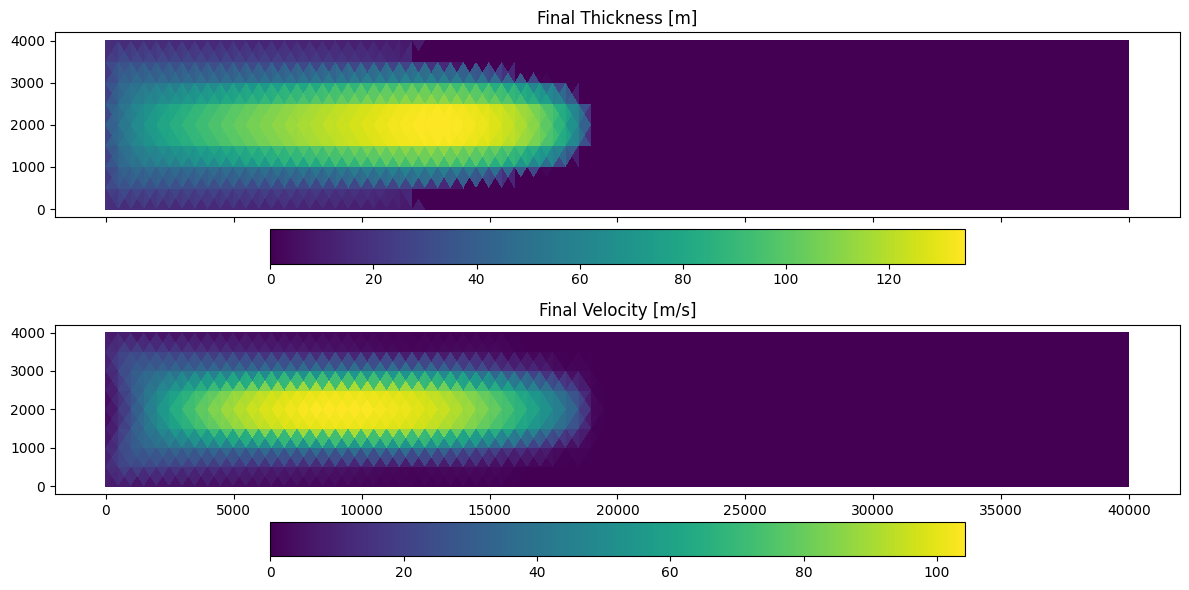

In [48]:
# Thickness Plot
fig, axes = plt.subplots(2, 1, figsize = (12,6), sharex = True)

axes[0].set_title('Final Thickness [m]')
colors = firedrake.tripcolor(hs[-1], num_sample_points=1, shading="flat", axes=axes[0])
fig.colorbar(colors, orientation = 'horizontal', pad = 0.05)

axes[1].set_title('Final Velocity [m/s]')
colors1 = firedrake.tripcolor(u, num_sample_points=1, shading="flat", axes=axes[1])
fig.colorbar(colors1, orientation = 'horizontal', pad = 0.12)

fig.tight_layout()

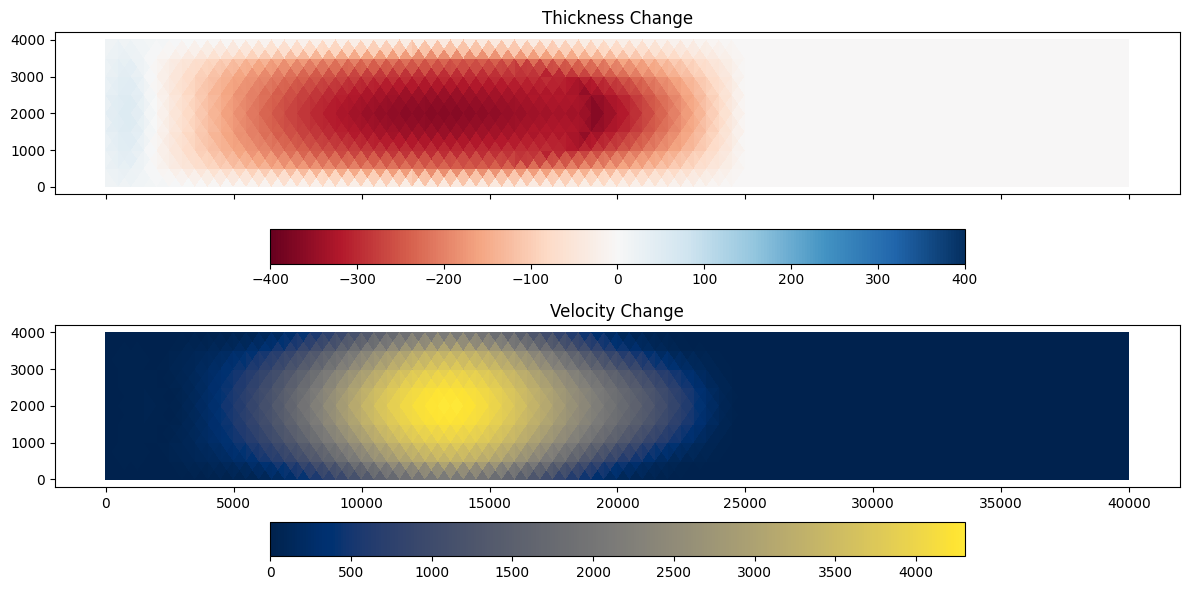

In [49]:
# difference plots
δh = firedrake.project(hs[-1] - hs[0], hs[0].function_space())
change_max = δh.dat.data_ro.max()
change_min = δh.dat.data_ro.min()

fig, axes = plt.subplots(2, 1, figsize = (12,6), sharex = True)
axes[0].set_title("Thickness Change")
colors = firedrake.tripcolor(δh, 
                             num_sample_points=1, 
                             shading="flat", 
                             cmap="RdBu",
                             vmin = -400, vmax = 400, 
                             axes=axes[0])
fig.colorbar(colors, orientation = 'horizontal')#, pad = 0.05)


δu = firedrake.project(us[-1] - us[0], us[0].function_space())
change_max = δh.dat.data_ro.max()
change_min = δh.dat.data_ro.min()

axes[1].set_title("Velocity Change")
colors1 = firedrake.tripcolor(δu, 
                             num_sample_points=1, 
                             shading="flat", 
                             cmap="cividis",
                             #vmin = 0, vmax = 2500, 
                             axes=axes[1])
fig.colorbar(colors1, orientation = 'horizontal')#, pad = 0.05)
fig.tight_layout()

Text(0, 0.5, 'Ice Volume ($km^3$)')

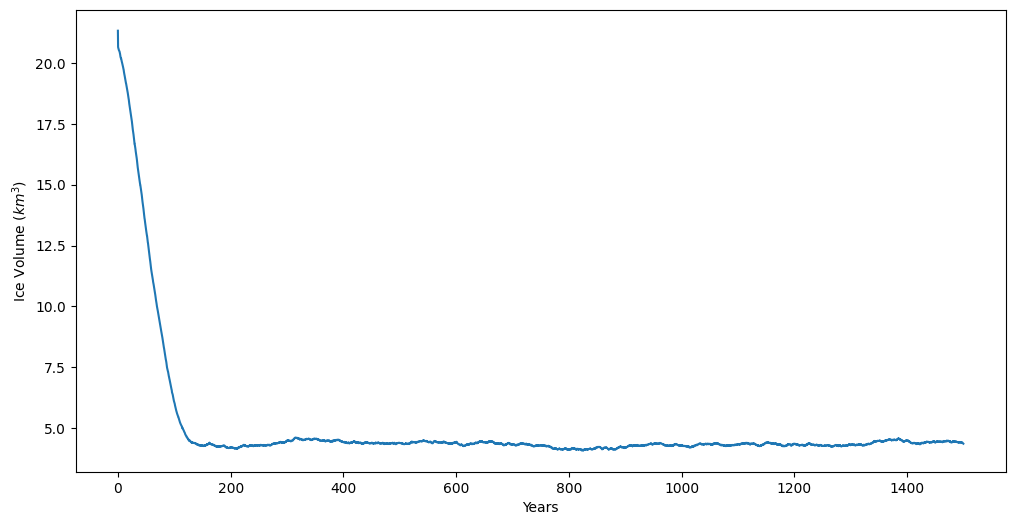

In [50]:
# Steady State Plot
volumes = np.array([firedrake.assemble(h*dx) / 1e9 for h in hs])

plt.figure(figsize = (12, 6))
plt.plot(timesteps, volumes)
plt.xlabel("Years")
plt.ylabel("Ice Volume ($km^3$)")

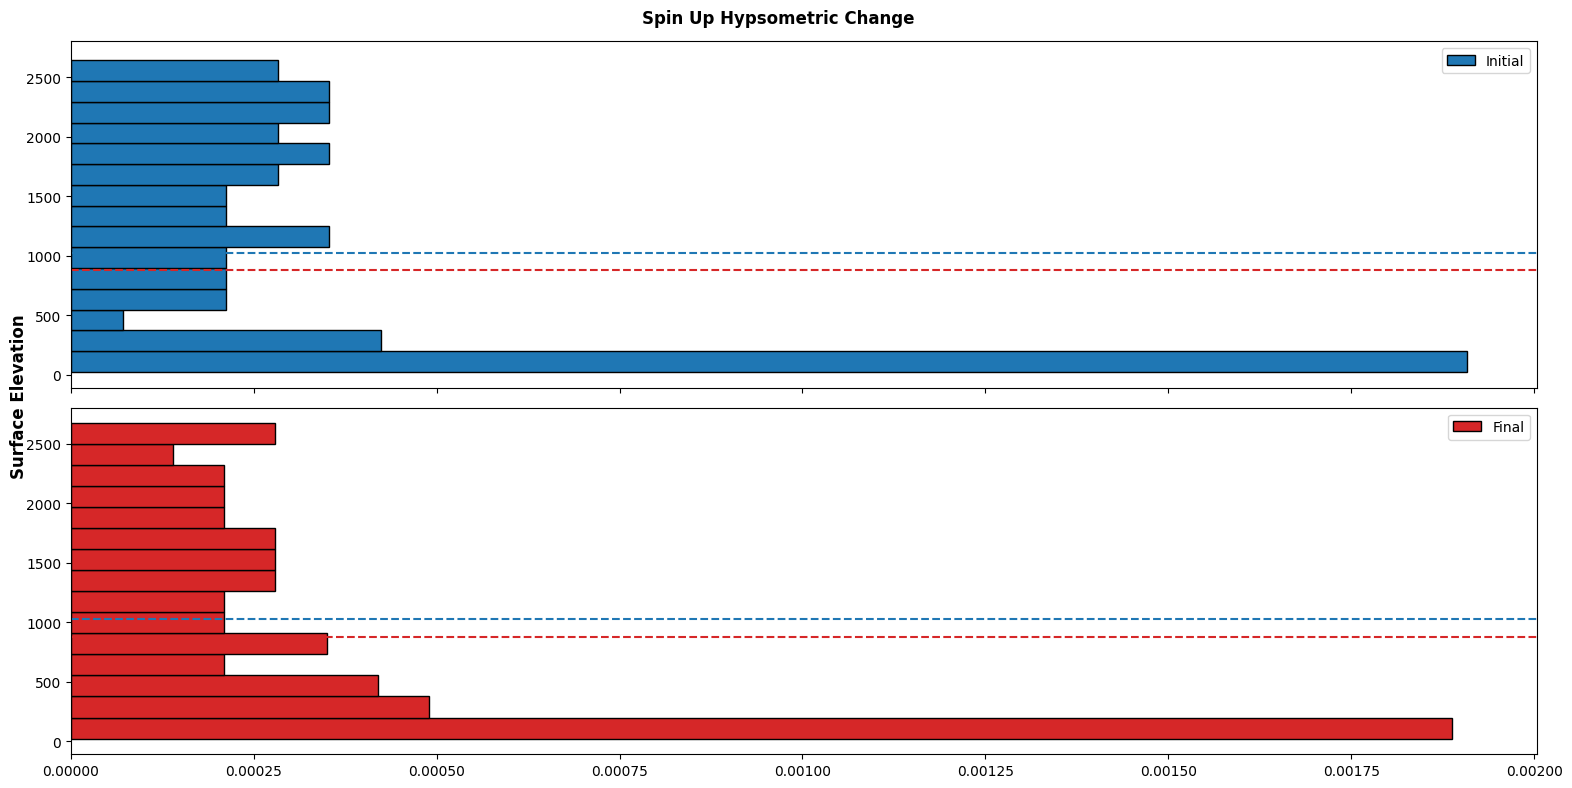

In [51]:
# Hypsometric Profile
sns_no_zeros = sns[sns != 0]
s0s_no_zeros = s0s[s0s != 0]

nbins = 15

fig, axes = plt.subplots(2, 1, figsize = (16, 8), sharex = True, sharey = True)
fig.suptitle('Spin Up Hypsometric Change', fontweight = 'bold')

axes[0].hist(s0s_no_zeros, bins = nbins, 
             color="tab:blue", 
             density = True, 
             label = "Initial", 
             edgecolor='black',
             orientation='horizontal')
axes[0].axhline(s0s_no_zeros.mean(), color = 'tab:blue', linestyle = 'dashed')
axes[0].axhline(sns_no_zeros.mean(), color = 'tab:red', linestyle = 'dashed')
axes[0].legend()

axes[1].hist(sns_no_zeros, bins = nbins, 
             color="tab:red", 
             density = True, 
             label = "Final", 
             edgecolor='black',
             orientation='horizontal')
axes[1].axhline(s0s.mean(), color = 'tab:blue', linestyle = 'dashed')
axes[1].axhline(sns_no_zeros.mean(), color = 'tab:red', linestyle = 'dashed')
axes[1].legend()


fig.supylabel("Surface Elevation ", fontweight = 'bold')
fig.tight_layout()

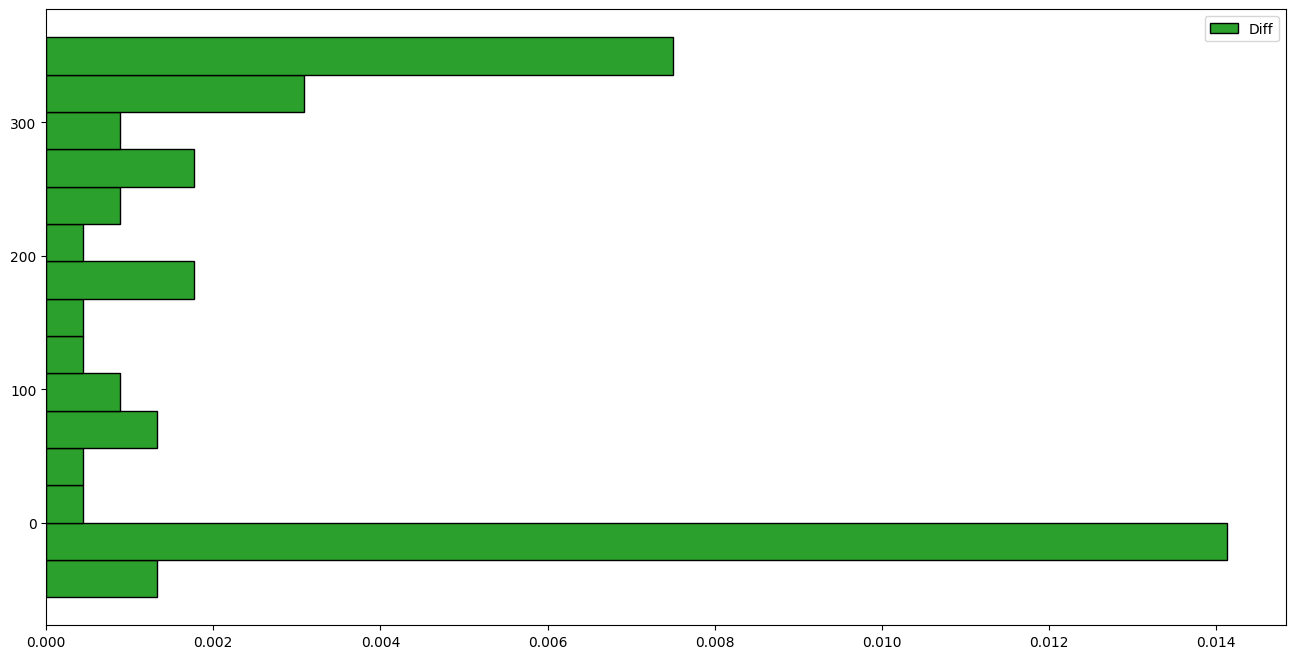

In [52]:
surf_diff = s0s - sns

fig, axes = plt.subplots(figsize = (16, 8), sharex = True, sharey = True)
axes.hist(surf_diff, bins = nbins, 
             color="tab:green", 
             density = True, 
             label = "Diff", 
             edgecolor='black',
             orientation='horizontal')
axes.legend()

## To Do
- Perturbations
- Floating Term. 
- SIA - Hybrid - SSA Exp.